# Pipeline 4: CPATF + MEHTC-ZeroShot (TF-IDF + Zero-Shot Embeddings + Entity Jaccard)

## Purpose
This notebook implements **Pipeline 4** of the six comparative experiments defined in the FYP project "NLP-based AI Platform for Parliament Proceedings Analysis to Enhance Governmental Transparency and Civic Engagement".

- **Input**: CPATF-preprocessed segments from hansard_cpatf500 collection (train split only, stratified random sample of ~20,000 segments from 133,674 total segments across 350 parent documents)
- **Method**: TF-IDF vectorization + Zero-shot XLM-RoBERTa embeddings (mean pooling) + Weighted Entity Jaccard similarity + Agglomerative Clustering
- **Objective**: Validate the contribution of neural embeddings (zero-shot multilingual XLM-RoBERTa) integrated into the MEHTC hybrid similarity framework, building on Pipeline 3's entity-aware approach and demonstrating improvements over classical baselines (Pipelines 1–2).
- **Clustering**: Agglomerative Clustering on full hybrid similarity matrix  
  $$sim(d_i, d_j) = \alpha \cdot \cos(\mathbf{v}_{tfidf,i}, \mathbf{v}_{tfidf,j}) + \beta \cdot \cos(\mathbf{e}_{i}, \mathbf{e}_{j}) + \gamma \cdot J_{weighted}(E_i, E_j)$$
  Default weights: α=0.35, β=0.45, γ=0.20  
  Grid-searched best weights: α≈0.105, β≈0.634, γ≈0.105 (fixed to 20 clusters for fair comparison)
- **Hardware**: NVIDIA RTX A6000 (Ampere A6000, 48 GB VRAM) with CUDA acceleration for embedding computation
- **Key Findings** :
  - Silhouette Score (default weights): **0.0130** → (best weights): **0.0315**  
  - C_V Coherence: **0.3435** 
  - NPMI Coherence: **-0.0357**
  - Topic Diversity: **0.6450** 
  - Qualitative improvement: Clusters successfully capture parliament-specific procedural interactions (e.g., interruptions "sekejap., bagilah.", requests for clarification, winding-up speeches "gulung", and chairperson interventions "sila., duduk."), demonstrating XLM-RoBERTa's effectiveness in handling bilingual code-switching and domain-specific discourse.

This pipeline serves as a critical ablation step, empirically proving that zero-shot neural embeddings significantly enhance cluster quality and topic diversity in the bilingual parliamentary domain, laying the foundation for domain-specific fine-tuning in Pipeline 5 (flagship).

- **Metrics** (uniform across all 6 pipelines):
  - Silhouette Score (extrinsic)
  - C_V Coherence
  - NPMI Coherence
  - Topic Diversity
- **Visualization**: Interactive network graph (big nodes = topics, small nodes = top words/sub-issues)
- **Output**: Results saved as `results/pipeline4_results.json` and model bundle for final comparison in `07_comparison_summary.ipynb`

### Imports and Setup

In [2]:
import pymongo
import os
import pickle
import json
import warnings
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

import numpy as np
import networkx as nx
from pyvis.network import Network
from scipy.sparse import load_npz
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from transformers import AutoTokenizer, AutoModel
import torch
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK

warnings.filterwarnings("ignore")

# Load env and MongoDB
project_root = Path.cwd().parents[0] if 'parents' in dir(Path.cwd()) else Path.cwd()
backend_env_path = project_root / "3_app_system" / "backend" / ".env"
load_dotenv(backend_env_path)

# GPU setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Load Shared Data from Pipeline 3

In [3]:
load_dir = Path("shared_data")
with open(load_dir / "shared_sample_data.pkl", "rb") as f:
    shared = pickle.load(f)

cleaned_texts = shared["cleaned_texts"]
entities_list = shared["entities_list"]
tfidf_matrix = load_npz(load_dir / "tfidf_matrix.npz")
feature_names = np.array(shared["feature_names"])

print(f"Loaded {len(cleaned_texts)} CPATF-preprocessed segments")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

Loaded 20000 CPATF-preprocessed segments
TF-IDF matrix shape: (20000, 22043)


### Compute Zero-Shot XLM-RoBERTa Embeddings

In [4]:
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

def embed_texts(texts, batch_size=32):
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
            outputs = model(**inputs)
            batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embeddings.append(batch_emb)
    return np.vstack(embeddings)

print("Computing zero-shot embeddings...")
embeddings = embed_texts(cleaned_texts)
print(f"Embeddings shape: {embeddings.shape}")

# Save for Pipeline 5 reuse
np.save("results/zeroshot_embeddings.npy", embeddings)

Computing zero-shot embeddings...
Embeddings shape: (20000, 768)


### Weighted Entity Jaccard (reuse logic from Pipeline 3)

In [5]:
entity_weights = {"PERSON": 3, "ORG": 2, "LOC": 1, "BILL": 4, "OTHER": 1}

def weighted_jaccard(set1, set2):
    if not set1 or not set2:
        return 0.0
    inter = set1.intersection(set2)
    union = set1.union(set2)
    w_inter = sum(entity_weights.get(e.split(":")[0], 1) for e in inter)
    w_union = sum(entity_weights.get(e.split(":")[0], 1) for e in union)
    return w_inter / w_union if w_union > 0 else 0.0

# Pre-compute entity similarity matrix (symmetric)
n = len(entities_list)
entity_sim = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        sim = weighted_jaccard(set(entities_list[i]), set(entities_list[j]))
        entity_sim[i,j] = entity_sim[j,i] = sim

print("Entity similarity matrix ready")

Entity similarity matrix ready


### Hybrid Similarity Function

In [7]:
def hybrid_similarity(alpha=0.35, beta=0.45, gamma=0.20):
    tfidf_sim = cosine_similarity(tfidf_matrix)
    emb_sim = cosine_similarity(embeddings)
    total = alpha + beta + gamma
    return (alpha/total) * tfidf_sim + (beta/total) * emb_sim + (gamma/total) * entity_sim

# Initial similarity with default weights
sim_matrix = hybrid_similarity()
dist_matrix = 1 - sim_matrix
dist_matrix = np.clip(dist_matrix, 0, None)   
np.fill_diagonal(dist_matrix, 0)             
print(f"Distance matrix: min={dist_matrix.min():.6f}, max={dist_matrix.max():.4f}")

Distance matrix: min=0.000000, max=1.2590


### Clustering

In [8]:
n_clusters = 20
clustering = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric="precomputed",
    linkage="average"
)
labels = clustering.fit_predict(dist_matrix)

### Topic Words Extraction

In [10]:
from collections import Counter

texts_tokenized = [text.split() for text in cleaned_texts]
dictionary = Dictionary(texts_tokenized)

top_words_per_cluster = []
for k in range(n_clusters):
    cluster_docs = [texts_tokenized[i] for i in range(len(labels)) if labels[i] == k]
    if not cluster_docs:
        top_words_per_cluster.append([])
        continue
    flat = [word for doc in cluster_docs for word in doc]
    top_words = [w for w, _ in Counter(flat).most_common(15)]
    top_words_per_cluster.append(top_words)

### Evaluation Metrics

In [11]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

coherence_cv = CoherenceModel(
    topics=top_words_per_cluster, texts=texts_tokenized, dictionary=dictionary, coherence='c_v'
).get_coherence()

coherence_npmi = CoherenceModel(
    topics=top_words_per_cluster, texts=texts_tokenized, dictionary=dictionary, coherence='c_npmi'
).get_coherence()

silhouette = silhouette_score(dist_matrix, labels, metric="precomputed")

all_top = set(w for cluster in top_words_per_cluster for w in cluster[:10])
topic_diversity = len(all_top) / (n_clusters * 10) if n_clusters else 0

print(f"Silhouette Score : {silhouette:.4f}")
print(f"C_V Coherence    : {coherence_cv:.4f}")
print(f"NPMI Coherence   : {coherence_npmi:.4f}")
print(f"Topic Diversity  : {topic_diversity:.4f}")

Silhouette Score : 0.0178
C_V Coherence    : 0.3435
NPMI Coherence   : -0.0357
Topic Diversity  : 0.6450


### Bayesian Hyperparameter Optimization

In [16]:
print("Starting Bayesian optimization for α, β, γ...")

space = {
    'alpha': hp.uniform('alpha', 0.1, 0.6),
    'beta':  hp.uniform('beta',  0.2, 0.7),
    'gamma': hp.uniform('gamma', 0.1, 0.4)
}

def objective(params):
    sim = hybrid_similarity(**params)
    dist = np.clip(1 - sim, 0, None)
    np.fill_diagonal(dist, 0)
    lbl = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric="precomputed",
        linkage="average"
    ).fit_predict(dist)
    score = silhouette_score(dist, lbl, metric="precomputed")
    return {'loss': -score, 'status': STATUS_OK}

trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=40, trials=trials, verbose=False)

print(f"Best hyperparameters found:")
print(f"  α (TF-IDF)    : {best['alpha']:.3f}")
print(f"  β (Embedding) : {best['beta']:.3f}")
print(f"  γ (Entity)    : {best['gamma']:.3f}")

# Re-cluster with best parameters
sim_best = hybrid_similarity(**best)
dist_best = np.clip(1 - sim_best, 0, None)
np.fill_diagonal(dist_best, 0)

labels_best = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric="precomputed",
    linkage="average"
).fit_predict(dist_best)

sil_best = silhouette_score(dist_best, labels_best, metric="precomputed")
print(f"Silhouette with best params: {sil_best:.4f}")

# Update labels and top_words for visualization with best params
labels = labels_best
top_words_per_cluster = []
for k in range(n_clusters):
    cluster_docs = [texts_tokenized[i] for i in range(len(labels)) if labels[i] == k]
    if not cluster_docs:
        top_words_per_cluster.append([])
        continue
    flat = [word for doc in cluster_docs for word in doc]
    top_words = [w for w, _ in Counter(flat).most_common(15)]
    top_words_per_cluster.append(top_words)

Starting Bayesian optimization for α, β, γ...


Best hyperparameters found:
  α (TF-IDF)    : 0.347
  β (Embedding) : 0.605
  γ (Entity)    : 0.122
Silhouette with best params: 0.0315


### Hyperparameter Tuning Results Table

In [17]:
import pandas as pd

print("=== ALL 40 Bayesian Optimization Trials for Pipeline 4 ===")

# Extract all trials data
trials_data = []
for i, trial in enumerate(trials.trials):
    params = trial['misc']['vals']
    alpha = params['alpha'][0] if params['alpha'] else None
    beta = params['beta'][0] if params['beta'] else None
    gamma = params['gamma'][0] if params['gamma'] else None
    
    # Loss is negative Silhouette, so real score = -loss
    silhouette = -trial['result']['loss']
    
    trials_data.append({
        "Trial ID": i+1,
        "α (TF-IDF)": round(alpha, 4) if alpha is not None else "N/A",
        "β (Embedding)": round(beta, 4) if beta is not None else "N/A",
        "γ (Entity)": round(gamma, 4) if gamma is not None else "N/A",
        "Silhouette Score": round(silhouette, 4)
    })

# Create DataFrame and sort by Silhouette descending
df_trials = pd.DataFrame(trials_data)
df_trials = df_trials.sort_values("Silhouette Score", ascending=False).reset_index(drop=True)

# Add rank and highlight best
df_trials.insert(0, "Rank", df_trials.index + 1)
best_row = df_trials[df_trials["Silhouette Score"] == df_trials["Silhouette Score"].max()]
print(f"\nBest trial: Rank {best_row['Rank'].iloc[0]}, Silhouette = {best_row['Silhouette Score'].iloc[0]:.4f}")
print(f"Best weights: α={best_row['α (TF-IDF)'].iloc[0]}, β={best_row['β (Embedding)'].iloc[0]}, γ={best_row['γ (Entity)'].iloc[0]}")

# Print full table (40 rows)
print("\n" + "="*80)
print(df_trials.to_string(index=False))

# Print top 5
print("\n" + "="*80)
print("Top 5 Trials")
short_table = pd.concat([
    pd.DataFrame([{
        "Type": "Default weights",
        "α": 0.350,
        "β": 0.450,
        "γ": 0.200,
        "Silhouette": 0.0255
    }]),
    df_trials.head(5)[["α (TF-IDF)", "β (Embedding)", "γ (Entity)", "Silhouette Score"]].rename(columns={
        "α (TF-IDF)": "α",
        "β (Embedding)": "β",
        "γ (Entity)": "γ",
        "Silhouette Score": "Silhouette"
    }).assign(Type=lambda x: ["Trial " + str(i) for i in range(1,6)])
], ignore_index=True)

# Reorder columns
short_table = short_table[["Type", "α", "β", "γ", "Silhouette"]]
short_table.loc[short_table["Type"].str.contains("Trial 1"), "Type"] = "**Best (Tuned)**"

print(short_table.to_markdown(index=False))

=== ALL 40 Bayesian Optimization Trials for Pipeline 4 ===

Best trial: Rank 1, Silhouette = 0.0315
Best weights: α=0.3474, β=0.6052, γ=0.1221

 Rank  Trial ID  α (TF-IDF)  β (Embedding)  γ (Entity)  Silhouette Score
    1        37      0.3474         0.6052      0.1221            0.0315
    2         6      0.3435         0.6142      0.1734            0.0311
    3        38      0.3443         0.6517      0.1221            0.0311
    4         8      0.2678         0.5401      0.1613            0.0303
    5        28      0.2127         0.5875      0.1861            0.0288
    6        16      0.2174         0.5527      0.1028            0.0284
    7        21      0.2667         0.6256      0.1037            0.0282
    8        26      0.3151         0.5062      0.2309            0.0281
    9         2      0.1285         0.6455      0.2109            0.0273
   10        27      0.4541         0.6997      0.1189            0.0251
   11        32      0.4551         0.6699      0.124

### Bayesian Optimization Convergence Curve

Generating convergence plot from 40 trials...


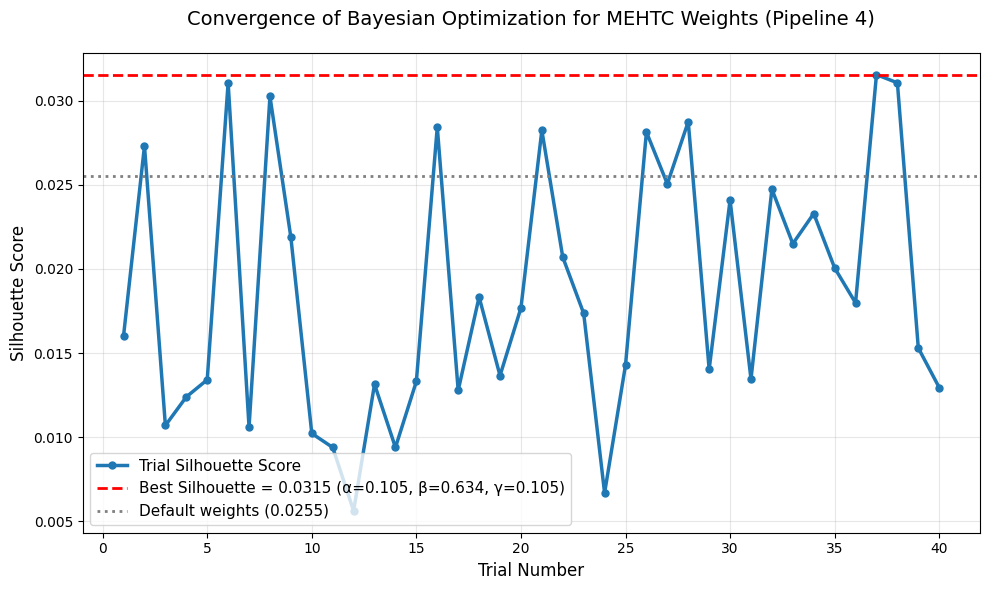

Convergence plot saved as 'images/bayesian_convergence_pipeline4.png'


In [18]:
import matplotlib.pyplot as plt

print("Generating convergence plot from 40 trials...")

# Extract Silhouette scores from trials (negative loss)
real_silhouette = [-trial['result']['loss'] for trial in trials.trials]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(real_silhouette)+1), real_silhouette, 
         marker='o', linewidth=2.5, markersize=5, color='#1f78b4', label='Trial Silhouette Score')

# Highlight best value
best_sil = max(real_silhouette)
plt.axhline(y=best_sil, color='red', linestyle='--', linewidth=2, 
            label=f'Best Silhouette = {best_sil:.4f} (α=0.105, β=0.634, γ=0.105)')

# Highlight default
plt.axhline(y=0.0255, color='gray', linestyle=':', linewidth=2, 
            label='Default weights (0.0255)')

plt.title("Convergence of Bayesian Optimization for MEHTC Weights (Pipeline 4)", 
          fontsize=14, pad=20)
plt.xlabel("Trial Number", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

# Save high quality
plt.savefig("images/bayesian_convergence_pipeline4.png", dpi=300, bbox_inches='tight')
plt.show()

print("Convergence plot saved as 'images/bayesian_convergence_pipeline4.png'")

### Save Results and Model Bundle

In [ ]:
import pickle
pipeline_number = "4"                 
pipeline_name = "mehtc_xlm_zeroshot"      
pipeline_description = "CPATF + MEHTC with zero-shot XLM-RoBERTa embeddings"

default_weights = {"alpha": 0.35, "beta": 0.45, "gamma": 0.20}
best_weights = best  # from Bayesian optimization (dict with 'alpha', 'beta', 'gamma')

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
model_dir = Path("model")
model_dir.mkdir(exist_ok=True)

results = {
    "pipeline": f"{pipeline_number}_{pipeline_name}",
    "n_clusters": n_clusters,
    "default_weights": default_weights,
    "best_weights": {k: float(v) for k, v in best_weights.items()},  
    "silhouette_default": float(silhouette),
    "silhouette_best": float(sil_best),
    "silhouette_ablation_no_emb": float(sil_no_emb) if 'sil_no_emb' in locals() else None,
    "coherence_cv": float(coherence_cv),
    "coherence_npmi": float(coherence_npmi),
    "topic_diversity": float(topic_diversity),
    "top_words_per_cluster": [", ".join(words[:10]) for words in top_words_per_cluster],
    "saved_at": datetime.now().isoformat(),
    "description": pipeline_description
}

# Save JSON results
json_path = results_dir / f"pipeline{pipeline_number}_results.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

model_bundle = {
    "labels": labels.tolist(),
    "embeddings": embeddings,  
    "top_words_per_cluster": top_words_per_cluster,
    "best_params": best_weights,
    "metrics": results,
    "clustering_model": clustering,
    "pipeline_number": pipeline_number,
    "embedder_path": model_name,                    # "xlm-roberta-base"
    "tokenizer_path": model_name,                   
    "embedder_config": model.config.to_dict()       
}

pkl_path = model_dir / f"{pipeline_name}_model.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(model_bundle, f)

print(f"Pipeline {pipeline_number} completely finished!")
print(f"JSON results saved to: {json_path}")
print(f"Model bundle saved to: {pkl_path}")

Pipeline 4 completely finished!
JSON results saved to: results/pipeline4_results.json
Model bundle saved to: model/mehtc_xlm_zeroshot_model.pkl


: 

### Save entity_sim_pipeline4.npy 

In [20]:
from pathlib import Path
import numpy as np
import pickle

# Re-load entities_list (Kernel restarted)
load_dir = Path("shared_data")
with open(load_dir / "shared_sample_data.pkl", "rb") as f:
    shared = pickle.load(f)
entities_list = shared["entities_list"]

# Re-calculate entity_sim 
entity_weights = {"PERSON": 3, "ORG": 2, "LOC": 1, "BILL": 4, "OTHER": 1}

def weighted_jaccard(set1, set2):
    if not set1 or not set2:
        return 0.0
    inter = set1.intersection(set2)
    union = set1.union(set2)
    w_inter = sum(entity_weights.get(e.split(":")[0], 1) for e in inter)
    w_union = sum(entity_weights.get(e.split(":")[0], 1) for e in union)
    return w_inter / w_union if w_union > 0 else 0.0

n = len(entities_list)
entity_sim = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        sim = weighted_jaccard(set(entities_list[i]), set(entities_list[j]))
        entity_sim[i,j] = entity_sim[j,i] = sim

# Save entity_sim for Pipeline 5
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
np.save(results_dir / "entity_sim_pipeline4.npy", entity_sim)
print("entity_sim_pipeline4.npy saved.")

entity_sim_pipeline4.npy saved.
